In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.plot_styles import *

In [7]:

input_filenames = [
        "Volume_CSV/results.csv",
        ]

labels = [
        r'89x41',
]
lstyles = [
        '--',
]


In [8]:
# reference quantities
p_ref = 100000
T_ref = 300
Rair = 287.058
gamma = 1.4
M_ref = 0.2
rho_ref = p_ref / (Rair * T_ref)
a_ref = np.sqrt(gamma * Rair * T_ref)
q_ref = 0.5 * rho_ref * a_ref**2 * M_ref**2

nu_ref = 1.84e-5
mu_ref = nu_ref * rho_ref

In [9]:
datas = {}

for ii,input_filename in enumerate(input_filenames):
    with open(input_filename, 'r') as f:
            ni = int(f.readline().strip().split('=')[1])
            nj = int(f.readline().strip().split('=')[1])
            nk = int(f.readline().strip().split('=')[1])
        
    df = pd.read_csv(input_filename, skiprows=3)
    data = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    datas[ii] = data

In [10]:
# open nasa files
nasa_cp = np.loadtxt('../reference/cp_bump.dat', skiprows=2)
nasa_cf = np.loadtxt('../reference/cf_bump.dat', skiprows=2)

In [11]:
def compute_cp(p):
    return (p-p_ref) / 2/q_ref

def compute_cf(tau_x):
    return tau_x / 2/q_ref

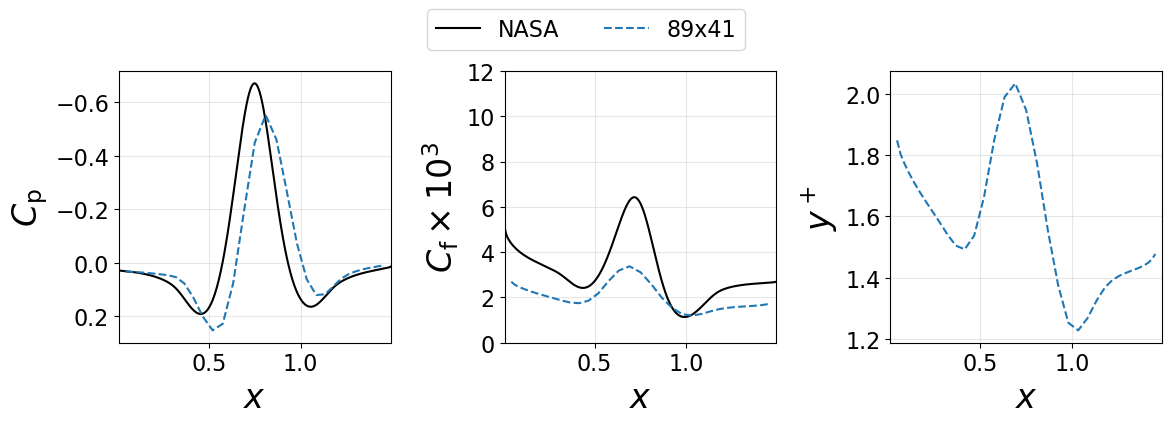

In [12]:
xmin = 0.03
xmax = 1.47

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].plot(nasa_cp[:, 0], nasa_cp[:, 1], label='NASA', color='k')
ax[1].plot(nasa_cf[:, 0], nasa_cf[:, 1]*1e3, color='k')

for key, data in datas.items():
    mask = (data['x'][:, 0, 0] > xmin) & (data['x'][:, 0, 0] < xmax)
    idx = np.where(mask)[0]

    p = data['Pressure'][idx, 0, 0]
    x = data['x'][idx, 0, 0]
    tau_x = data['Wall Shear Stress X'][idx, 0, 0]
    tau_y = data['Wall Shear Stress Y'][idx, 0, 0]
    tau = np.sqrt(tau_x**2 + tau_y**2)
    yplus = data['Y Plus'][idx, 0, 0]
    
    ax[0].plot(x, compute_cp(p), lstyles[key], mfc='none',label=labels[key])
    
    
    ax[1].plot(x, compute_cf(tau)*1e3, lstyles[key])
    ax[2].plot(x, yplus, lstyles[key])


fig.legend(ncol=len(input_filenames)+1, bbox_to_anchor=(0.5, 1.1), loc='upper center')
ax[0].invert_yaxis()
ax[0].set_ylabel(r'$C_{\rm p}$')
ax[0].set_xlabel(r'$x$')
ax[0].grid(alpha=0.3)
ax[0].set_xlim(0.01, 1.49)

ax[1].set_ylabel(r'$C_{\rm f} \times 10^3$')
ax[1].set_xlabel(r'$x$')
ax[1].grid(alpha=0.3)
ax[1].set_ylim(0, 12)
ax[1].set_xlim(0.01, 1.49)

ax[2].set_ylabel(r'$y^+$')
ax[2].set_xlabel(r'$x$')
ax[2].grid(alpha=0.3)
ax[2].set_xlim(0.01, 1.49)

fig.tight_layout()
fig.savefig('flatplate_results_comparison.pdf', bbox_inches='tight')


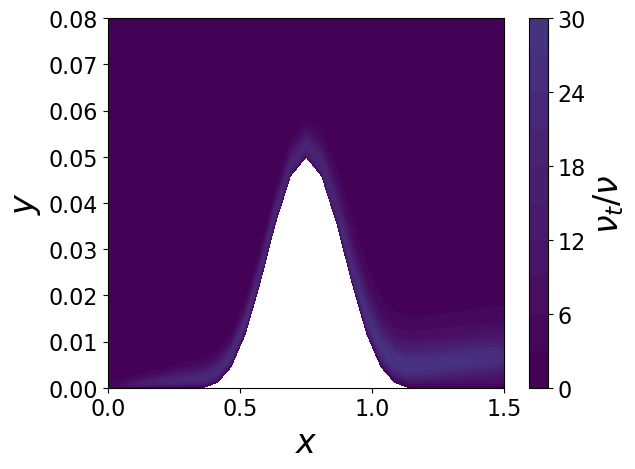

In [14]:
xmin = 0.0
xmax = 1.5
ymin = 0.00
ymax = 0.15

for key, data in datas.items():
    X = data['x'][:, :, 0]

    Y = data['y'][:, :, 0]

    EV = data['Eddy Viscosity Ratio'][:, :, 0]

    i_mask = np.any((X >= xmin) & (X <= xmax), axis=1)

    j_mask = np.any((Y >= ymin) & (Y <= ymax), axis=0)

    Xp = X[np.ix_(i_mask, j_mask)]

    Yp = Y[np.ix_(i_mask, j_mask)]

    ratio = EV[np.ix_(i_mask, j_mask)]

    plt.figure()

    plt.contourf(Xp, Yp, ratio, levels=10, cmap='viridis', vmin=0, vmax=200)
    plt.colorbar(label=r'$\nu_t / \nu$')
    
    # plt.contour(Xp, Yp, mu_t/mu_ref, levels=15, colors='r', linewidths=0.3)
    plt.ylim(ymin, 0.08)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
    